In [1]:
import numpy as np
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

In [2]:
X_train = np.load("../data/processed/X_train.npy")
X_val = np.load("../data/processed/X_val.npy")
X_test = np.load("../data/processed/X_test.npy")

y_train = np.load("../data/processed/y_train.npy")
y_val = np.load("../data/processed/y_val.npy")
y_test = np.load("../data/processed/y_test.npy")

feature_names = np.load(
    "../data/processed/feature_names.npy",
    allow_pickle=True
)

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)
print("Features:", len(feature_names))

Training: (39846, 15) (39846,)
Validation: (8539, 15) (8539,)
Test: (8539, 15) (8539,)
Features: 15


In [3]:
y_val_baseline = np.zeros_like(y_val)

baseline_accuracy = accuracy_score(y_val, y_val_baseline)
baseline_precision = precision_score(
    y_val,
    y_val_baseline,
    zero_division=0
)
baseline_recall = recall_score(
    y_val,
    y_val_baseline
)
baseline_f1 = f1_score(
    y_val,
    y_val_baseline
)

print("Baseline Accuracy:", baseline_accuracy)
print("Baseline Precision:", baseline_precision)
print("Baseline Recall:", baseline_recall)
print("Baseline F1:", baseline_f1)

Baseline Accuracy: 0.9090057383768592
Baseline Precision: 0.0
Baseline Recall: 0.0
Baseline F1: 0.0


In [4]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [5]:
y_val_pred = log_reg.predict(X_val)

y_val_prob = log_reg.predict_proba(X_val)[:, 1]

print("Predictions created:", len(y_val_pred))
print("Probabilities created:", len(y_val_prob))

Predictions created: 8539
Probabilities created: 8539


In [6]:
logreg_accuracy = accuracy_score(y_val, y_val_pred)
logreg_precision = precision_score(y_val, y_val_pred, zero_division=0)
logreg_recall = recall_score(y_val, y_val_pred)
logreg_f1 = f1_score(y_val, y_val_pred)
logreg_pr_auc = average_precision_score(y_val, y_val_prob)

print("Logistic Regression Validation Metrics")
print("--------------------------------------")
print("Accuracy:", logreg_accuracy)
print("Precision:", logreg_precision)
print("Recall:", logreg_recall)
print("F1 Score:", logreg_f1)
print("PR-AUC:", logreg_pr_auc)

Logistic Regression Validation Metrics
--------------------------------------
Accuracy: 0.9231760159269236
Precision: 0.6170212765957447
Recall: 0.41055341055341055
F1 Score: 0.49304482225656876
PR-AUC: 0.5491466137083295


In [7]:
cm = confusion_matrix(y_val, y_val_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[7564  198]
 [ 458  319]]


In [8]:
print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=["Legitimate", "Laundering"]
    )
)

              precision    recall  f1-score   support

  Legitimate       0.94      0.97      0.96      7762
  Laundering       0.62      0.41      0.49       777

    accuracy                           0.92      8539
   macro avg       0.78      0.69      0.73      8539
weighted avg       0.91      0.92      0.92      8539



In [9]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [12]:
rf_val_pred = random_forest.predict(X_val)

rf_val_prob = random_forest.predict_proba(X_val)[:, 1]

print("Predictions created:", len(rf_val_pred))
print("Probabilities created:", len(rf_val_prob))

Predictions created: 8539
Probabilities created: 8539


In [13]:
rf_accuracy = accuracy_score(y_val, rf_val_pred)
rf_precision = precision_score(y_val, rf_val_pred, zero_division=0)
rf_recall = recall_score(y_val, rf_val_pred)
rf_f1 = f1_score(y_val, rf_val_pred)
rf_pr_auc = average_precision_score(y_val, rf_val_prob)

print("Random Forest Validation Metrics")
print("--------------------------------")
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)
print("PR-AUC:", rf_pr_auc)

Random Forest Validation Metrics
--------------------------------
Accuracy: 0.9284459538587657
Precision: 0.6321656050955414
Recall: 0.510939510939511
F1 Score: 0.5651245551601424
PR-AUC: 0.6228009715231719


In [14]:
rf_cm = confusion_matrix(y_val, rf_val_pred)

print("Random Forest Confusion Matrix:")
print(rf_cm)

Random Forest Confusion Matrix:
[[7531  231]
 [ 380  397]]


In [15]:
print(
    classification_report(
        y_val,
        rf_val_pred,
        target_names=["Legitimate", "Laundering"]
    )
)

              precision    recall  f1-score   support

  Legitimate       0.95      0.97      0.96      7762
  Laundering       0.63      0.51      0.57       777

    accuracy                           0.93      8539
   macro avg       0.79      0.74      0.76      8539
weighted avg       0.92      0.93      0.92      8539



In [16]:
balanced_rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

balanced_rf.fit(X_train, y_train)

print("Balanced Random Forest trained successfully.")

Balanced Random Forest trained successfully.


In [17]:
balanced_rf_val_pred = balanced_rf.predict(X_val)

balanced_rf_val_prob = balanced_rf.predict_proba(X_val)[:, 1]

print("Predictions created:", len(balanced_rf_val_pred))
print("Probabilities created:", len(balanced_rf_val_prob))

Predictions created: 8539
Probabilities created: 8539


In [18]:
balanced_rf_accuracy = accuracy_score(y_val, balanced_rf_val_pred)
balanced_rf_precision = precision_score(
    y_val,
    balanced_rf_val_pred,
    zero_division=0
)
balanced_rf_recall = recall_score(y_val, balanced_rf_val_pred)
balanced_rf_f1 = f1_score(y_val, balanced_rf_val_pred)
balanced_rf_pr_auc = average_precision_score(
    y_val,
    balanced_rf_val_prob
)

print("Balanced Random Forest Validation Metrics")
print("-----------------------------------------")
print("Accuracy:", balanced_rf_accuracy)
print("Precision:", balanced_rf_precision)
print("Recall:", balanced_rf_recall)
print("F1 Score:", balanced_rf_f1)
print("PR-AUC:", balanced_rf_pr_auc)

Balanced Random Forest Validation Metrics
-----------------------------------------
Accuracy: 0.9291486122496779
Precision: 0.6400651465798045
Recall: 0.5057915057915058
F1 Score: 0.5650611071171819
PR-AUC: 0.6198129924455374


In [19]:
balanced_rf_cm = confusion_matrix(
    y_val,
    balanced_rf_val_pred
)

print("Balanced Random Forest Confusion Matrix:")
print(balanced_rf_cm)

Balanced Random Forest Confusion Matrix:
[[7541  221]
 [ 384  393]]


In [20]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Balanced Random Forest"
    ],
    "Accuracy": [
        logreg_accuracy,
        rf_accuracy,
        balanced_rf_accuracy
    ],
    "Precision": [
        logreg_precision,
        rf_precision,
        balanced_rf_precision
    ],
    "Recall": [
        logreg_recall,
        rf_recall,
        balanced_rf_recall
    ],
    "F1": [
        logreg_f1,
        rf_f1,
        balanced_rf_f1
    ],
    "PR-AUC": [
        logreg_pr_auc,
        rf_pr_auc,
        balanced_rf_pr_auc
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,PR-AUC
0,Logistic Regression,0.9232,0.6170,0.4106,0.4930,0.5491
1,Random Forest,0.9284,0.6322,0.5109,0.5651,0.6228
2,Balanced Random Forest,0.9291,0.6401,0.5058,0.5651,0.6198


In [21]:
thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]

threshold_results = []

for threshold in thresholds:
    predictions = (rf_val_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_val, predictions, zero_division=0
        ),
        "Recall": recall_score(y_val, predictions),
        "F1": f1_score(y_val, predictions),
        "Flagged Transactions": predictions.sum()
    })

threshold_table = pd.DataFrame(threshold_results)

threshold_table.round(4)

,Threshold,Precision,Recall,F1,Flagged Transactions
0,0.1,0.4486,0.8250,0.5811,1429
1,0.2,0.5156,0.7465,0.6099,1125
2,0.3,0.5426,0.6564,0.5941,940
3,0.4,0.6003,0.5779,0.5889,748
4,0.5,0.6313,0.5135,0.5664,632
5,0.6,0.6775,0.4569,0.5457,524
6,0.7,0.7284,0.3900,0.5080,416


In [22]:
thresholds_fine = np.arange(0.01, 1.00, 0.01)

fine_results = []

for threshold in thresholds_fine:
    predictions = (rf_val_prob >= threshold).astype(int)

    fine_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_val, predictions, zero_division=0
        ),
        "Recall": recall_score(y_val, predictions),
        "F1": f1_score(y_val, predictions),
        "Flagged Transactions": predictions.sum()
    })

fine_threshold_table = pd.DataFrame(fine_results)

best_f1_row = fine_threshold_table.loc[
    fine_threshold_table["F1"].idxmax()
]

print("Best threshold by F1:")
print(best_f1_row)

Best threshold by F1:
Threshold                  0.210000
Precision                  0.521739
Recall                     0.741313
F1                         0.612440
Flagged Transactions    1104.000000
Name: 20, dtype: float64


In [23]:
recall_targets = [0.70, 0.75, 0.80, 0.90]

for target in recall_targets:
    eligible = fine_threshold_table[
        fine_threshold_table["Recall"] >= target
    ]

    if len(eligible) > 0:
        best = eligible.loc[eligible["Precision"].idxmax()]

        print(f"Recall target >= {target:.0%}")
        print(f"Threshold: {best['Threshold']:.2f}")
        print(f"Precision: {best['Precision']:.3f}")
        print(f"Recall: {best['Recall']:.3f}")
        print(f"F1: {best['F1']:.3f}")
        print(
            f"Flagged transactions: "
            f"{int(best['Flagged Transactions'])}"
        )
        print()

Recall target >= 70%
Threshold: 0.25
Precision: 0.526
Recall: 0.700
F1: 0.600
Flagged transactions: 1035

Recall target >= 75%
Threshold: 0.19
Precision: 0.514
Recall: 0.754
F1: 0.611
Flagged transactions: 1140

Recall target >= 80%
Threshold: 0.13
Precision: 0.473
Recall: 0.804
F1: 0.596
Flagged transactions: 1322

Recall target >= 90%
Threshold: 0.01
Precision: 0.250
Recall: 0.903
F1: 0.392
Flagged transactions: 2803



In [24]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

feature_importance

,Feature,Importance
0,remainder__Log Amount Paid,0.503212
1,categorical__Payment Format_ACH,0.235513
2,remainder__Transaction Hour,0.104935
3,remainder__Day of Week,0.042897
4,categorical__Payment Format_Cheque,0.030022
5,categorical__Payment Format_Credit Card,0.025087
6,remainder__Is Same Entity,0.011826
7,categorical__Payment Format_Cash,0.011773
8,remainder__Is Weekend,0.010167
9,remainder__Is Same Account,0.006811


In [25]:
clean_feature_importance = feature_importance.copy()

clean_feature_importance["Feature"] = (
    clean_feature_importance["Feature"]
    .str.replace("remainder__", "", regex=False)
    .str.replace("categorical__Payment Format_", "Payment Format: ", regex=False)
)

clean_feature_importance

,Feature,Importance
0,Log Amount Paid,0.503212
1,Payment Format: ACH,0.235513
2,Transaction Hour,0.104935
3,Day of Week,0.042897
4,Payment Format: Cheque,0.030022
5,Payment Format: Credit Card,0.025087
6,Is Same Entity,0.011826
7,Payment Format: Cash,0.011773
8,Is Weekend,0.010167
9,Is Same Account,0.006811


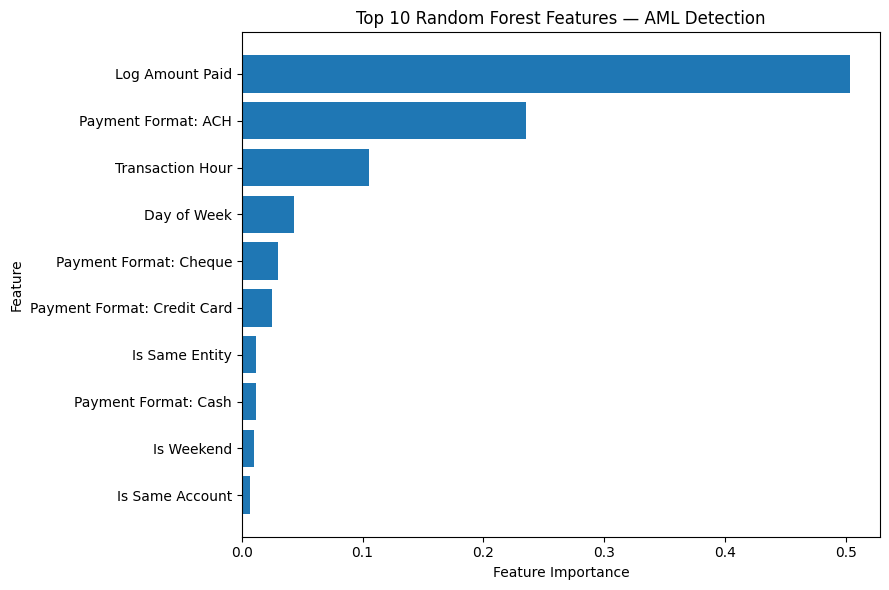

In [26]:
import matplotlib.pyplot as plt

top_features = clean_feature_importance.head(10).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Features — AML Detection")

plt.tight_layout()
plt.show()

In [27]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    random_forest,
    X_val,
    y_val,
    scoring="average_precision",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

permutation_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": perm_importance.importances_mean
})

permutation_df["Feature"] = (
    permutation_df["Feature"]
    .str.replace("remainder__", "", regex=False)
    .str.replace(
        "categorical__Payment Format_",
        "Payment Format: ",
        regex=False
    )
)

permutation_df = permutation_df.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

permutation_df

,Feature,Importance
0,Payment Format: ACH,0.376388
1,Log Amount Paid,0.257654
2,Transaction Hour,0.040011
3,Is Same Entity,0.036113
4,Payment Format: Cheque,0.032446
5,Payment Format: Credit Card,0.024078
6,Day of Week,0.022367
7,Is Weekend,0.013309
8,Is Cross Currency,0.007154
9,Is Same Account,0.005244


In [28]:
test_prob = random_forest.predict_proba(X_test)[:, 1]

final_threshold = 0.21

test_pred = (
    test_prob >= final_threshold
).astype(int)

print("Test predictions:", len(test_pred))
print("Threshold:", final_threshold)
print("Transactions flagged:", test_pred.sum())

Test predictions: 8539
Threshold: 0.21
Transactions flagged: 1161


In [29]:
test_accuracy = accuracy_score(y_test, test_pred)
test_precision = precision_score(
    y_test,
    test_pred,
    zero_division=0
)
test_recall = recall_score(y_test, test_pred)
test_f1 = f1_score(y_test, test_pred)
test_pr_auc = average_precision_score(
    y_test,
    test_prob
)

print("FINAL RANDOM FOREST TEST METRICS")
print("--------------------------------")
print("Accuracy:", test_accuracy)
print("Precision:", test_precision)
print("Recall:", test_recall)
print("F1 Score:", test_f1)
print("PR-AUC:", test_pr_auc)

FINAL RANDOM FOREST TEST METRICS
--------------------------------
Accuracy: 0.9118163719405082
Precision: 0.5099052540913006
Recall: 0.7628865979381443
F1 Score: 0.6112545172947857
PR-AUC: 0.6200606920287408


In [30]:
final_cm = confusion_matrix(
    y_test,
    test_pred
)

print("FINAL TEST CONFUSION MATRIX")
print("---------------------------")
print(final_cm)

FINAL TEST CONFUSION MATRIX
---------------------------
[[7194  569]
 [ 184  592]]


In [31]:
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    random_forest,
    "../models/aml_random_forest.joblib"
)

print("AML model saved successfully.")

AML model saved successfully.


In [32]:
threshold_config = {
    "model_name": "Random Forest",
    "threshold": 0.21,
    "validation_f1": 0.612440,
    "test_precision": 0.5099052540913006,
    "test_recall": 0.7628865979381443,
    "test_f1": 0.6112545172947857,
    "test_pr_auc": 0.6200606920287408
}

joblib.dump(
    threshold_config,
    "../models/aml_threshold_config.joblib"
)

print("AML threshold configuration saved.")

AML threshold configuration saved.


In [33]:
loaded_model = joblib.load("../models/aml_random_forest.joblib")
loaded_config = joblib.load("../models/aml_threshold_config.joblib")

print("Loaded model type:", type(loaded_model).__name__)
print("Loaded threshold:", loaded_config["threshold"])

Loaded model type: RandomForestClassifier
Loaded threshold: 0.21
